# Checkpoint Week 2 — SVM

Vul alle cellen in en push dit bestand naar je repo. De automatische checks (GitHub Actions) voeren dit notebook uit en controleren of alle **variabelen met de gevraagde namen** bestaan en correct zijn.

**BELANGRIJK**: gebruik exact de genoemde variabelennamen (`accuracy_breast_cancer`, `y_pred_breast_cancer`, `y_pred_digits`, `accuracy_digits`, `accuracy_wine`, `y_pred_svr`, `mse_svr`, `antwoord_scaling`, `antwoord_kernel`), anders faalt de controle.

**Gebruik in elke oefening `random_state=10` en `test_size=0.25`** bij de train/test-split, anders kunnen de checks afwijken.

---
# Oefening 1 — SVM op Breast Cancer

- Laad de breast cancer dataset via `sklearn.datasets.load_breast_cancer()`.
- Splits in train/test met `test_size=0.25` en `random_state=10`.
- **Normaliseer** met een StandardScaler (fit op train alleen!).
- Train een `SVC` met `random_state=10`.
- Sla de test-voorspellingen op in `y_pred_breast_cancer` en de **accuracy op de testset** in `accuracy_breast_cancer` (float).

In [28]:
import numpy as np
from sklearn import datasets #load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# TODO: laad de dataset
cancer = datasets.load_breast_cancer(as_frame=True)
# print(cancer)
X, y = cancer.data, cancer.target   

# TODO: train/test split (test_size=0.25, random_state=10)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=10)
# TODO: StandardScaler (fit op train alleen)
scaler = StandardScaler()
scaler.fit(X_train)
X_Train_scaled = scaler.fit_transform(X_train)
X_Test_scaled = scaler.transform(X_test)

# TODO: train SVC(random_state=10)
SVC_CLF = SVC(random_state=10)
SVC_CLF.fit(X_Train_scaled, y_train)
# TODO: voorspellingen in y_pred_breast_cancer en accuracy in accuracy_breast_cancer
y_pred_breast_cancer = SVC_CLF.predict(X_Test_scaled)
accuracy_breast_cancer = accuracy_score(y_test, y_pred_breast_cancer)

print(accuracy_breast_cancer)

0.9790209790209791


**Vraag (antwoord in antwoord_scaling)**: Waarom schalen we de features vóór een SVM? Kies A, B, C of D:
- A: Omdat SVM's alleen met integers werken
- B: Omdat SVM's afstand- en inwendig-productgebaseerd zijn en schaalverschillen anders de marge domineren
- C: Omdat de accuracy dan altijd 100% wordt
- D: Omdat sklearn dat vereist voor alle modellen

In [20]:
antwoord_scaling = "B"

---
# Oefening 2 — SVM op Digits (pipeline)

- Laad de digits dataset via `sklearn.datasets.load_digits()`.
- Splits in train/test met `test_size=0.25` en `random_state=10`.
- Gebruik een **pipeline** die StandardScaler en `SVC(random_state=10)` combineert.
- Sla de test-voorspellingen op in `y_pred_digits` en de **accuracy op de testset** in `accuracy_digits` (float).

In [68]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
# TODO: laad de digits dataset
digits = datasets.load_digits(as_frame=True)
# print(digits.head())
X,y = digits.data, digits.target
# TODO: train/test split (test_size=0.25, random_state=10)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=10)
# TODO: pipeline met StandardScaler + SVC(random_state=10), train en voorspel
SVC_pipeline = make_pipeline(StandardScaler(), SVC(kernel='linear',random_state=10),)

#self-study: PAST GRID-SEARCH toe om de beste kernel te vinden
param_grid = {'svc__kernel': ['linear', 'poly','rbf','sigmoid']}
grid_search = GridSearchCV(SVC_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print(f"best kernel: {grid_search.best_params_}")

SVC_pipeline.fit(X_train,y_train)
SVC_predictions = SVC_pipeline.predict(X_test)
# TODO: sla op in y_pred_digits en accuracy_digits
y_pred_digits = SVC_predictions
accuracy_digits = accuracy_score(y_test, y_pred_digits)

print(accuracy_digits)
print(SVC_pipeline.named_steps)
# print(SVC_pipeline, named.parameters)

best kernel: {'svc__kernel': 'linear'}
0.9822222222222222
{'standardscaler': StandardScaler(), 'svc': SVC(kernel='linear', random_state=10)}


**Vraag (antwoord in antwoord_kernel)**: Voor de digits-dataset, welke kernel presteert doorgaans het best? Kies A, B, C of D:
- A: linear
- B: poly
- C: rbf
- D: sigmoid

In [ ]:
antwoord_kernel = "A"

---
# Oefening 3 — SVM op Wine (meerklass)

- Laad de wine dataset via `sklearn.datasets.load_wine()`.
- Splits in train/test met `test_size=0.25` en `random_state=10`.
- Train een `SVC(random_state=10)` **in een pipeline met StandardScaler**.
- Sla de **accuracy op de testset** op in `accuracy_wine` (float).

In [76]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# TODO: laad de wine dataset
wines = datasets.load_wine(as_frame=True)
X,y = wines.data, wines.target
# TODO: train/test split (test_size=0.25, random_state=10)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=10)
# TODO: pipeline met StandardScaler + SVC(random_state=10)
pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=10))

param_grid = {'svc__kernel': ['linear', 'poly','rbf','sigmoid']}
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print(f"best kernel {grid_search.best_params_}")

pipe.fit(X_train, y_train)
y_predicted = pipe.predict(X_test)
# TODO: sla de test-accuracy op in accuracy_wine
accuracy_wine = accuracy_score(y_predicted, y_test)
print(accuracy_wine)

best kernel {'svc__kernel': 'rbf'}
0.9555555555555556


---
# Oefening 4 — SVR (regressie)

- Genereer de kwadratische dataset (staat al in de cel hieronder).
- Train een SVR met kernel `poly`, `degree=2`, `C=0.01`, `epsilon=0.1` in een pipeline met StandardScaler.
- Sla de voorspellingen op de trainingsdata op in `y_pred_svr` en de **MSE op de trainingsdata** in `mse_svr` (float).

0.010407700266361196


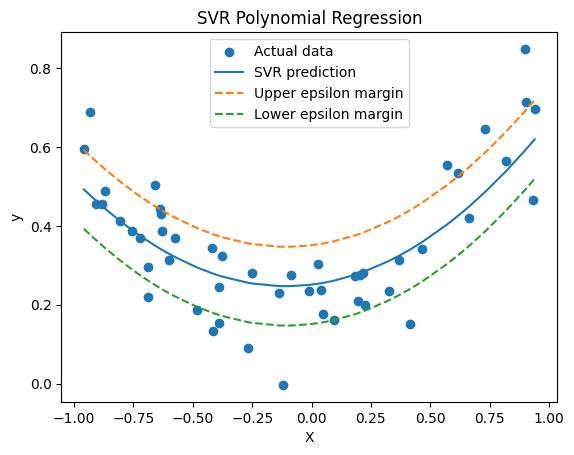

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

#SVC = SUPPORT VECTOR CATAGORIZED
#SVR = SUPPORT VECTOR REGRESSION
 
np.random.seed(42)

X = 2 * np.random.rand(50, 1) - 1
y = 0.2 + 0.1 * X[:, 0] + 0.5 * X[:, 0] ** 2 + np.random.randn(50) / 10

# Pipeline
pipe = make_pipeline(
    StandardScaler(),
    SVR(kernel='poly', degree=2, C=0.01, epsilon=0.1)
)

pipe.fit(X, y)

# Predict
y_pred_svr = pipe.predict(X)

# MSE
mse_svr = mean_squared_error(y, y_pred_svr)
print(mse_svr)

# Sort X so the lines are drawn smoothly
sort_idx = np.argsort(X[:, 0])
X_sorted = X[sort_idx]
y_pred_sorted = y_pred_svr[sort_idx]

# Error margin
epsilon = 0.1

upper_margin = y_pred_sorted + epsilon
lower_margin = y_pred_sorted - epsilon

# Original data
plt.scatter(X, y, label="Actual data")

# SVR prediction
plt.plot(
    X_sorted,
    y_pred_sorted,
    label="SVR prediction"
)

# Epsilon error margins
plt.plot(
    X_sorted,
    upper_margin,
    linestyle="--",
    label="Upper epsilon margin"
)

plt.plot(
    X_sorted,
    lower_margin,
    linestyle="--",
    label="Lower epsilon margin"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("SVR Polynomial Regression")
plt.legend()
plt.show()